1. Spark Application Setup
The application must initialize a valid environment:

Create a SparkSession with a clear application name.

Explicitly configure the master URL to local mode.

In [1]:
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
from pyspark.sql.types import *

spark = SparkSession.builder.appName("E_commerce").getOrCreate()

2. Data Ingestion & Validation
Validation Logic: Separate valid records from invalid/malformed records.

Audit: Report the total number of records vs. incomplete records.

Schema: Enforce an explicit schema (StructType) during the ingestion of valid data.

In [2]:
schema = StructType([
    StructField("product_id", StringType(), True),
    StructField("product_name", StringType(), True),
    StructField("brand", StringType(), True)
])

df = (
    spark.read.format("csv")
    .option("header", "true")
    .option("mode", "PERMISSIVE")
    .option("columnNameOfCorruptRecord", "_corrupt_record")
    .schema(schema)
    .load("/content/products.csv")

)

In [3]:
df.show()
df.count()

+----------+--------------------+-----------+
|product_id|        product_name|      brand|
+----------+--------------------+-----------+
|   PROD001|Wireless Noise Ca...|  TechSound|
|   PROD002|   Bluetooth Speaker|   AudioMax|
|   PROD003|Designer Leather ...| FashionHub|
|   PROD004|     Garden Tool Set|  GreenLife|
|   PROD005|Python Programmin...| BookMaster|
|   PROD006| 4K Smart TV 55 inch| VisionTech|
|   PROD007|Casual Cotton T-S...|  StyleWear|
|   PROD008|       Gaming Laptop|    TechPro|
|   PROD009|Data Science Hand...| LearnPress|
|   PROD010|Indoor Plant Pot Set|  HomeDecor|
|   PROD011|   Tennis Racket Pro|   SportMax|
|   PROD012| Digital Camera DSLR|  PhotoShot|
|   PROD013|Summer Dress Coll...|TrendyStyle|
|   PROD014|Classic Literatur...|  BookWorld|
|   PROD015|      Tablet 10 inch|   TechWave|
|   PROD016| Running Shoes Elite|  ActiveFit|
|   PROD017|     Kitchen Blender| CookMaster|
|   PROD018|        Evening Gown|ElegantWear|
|   PROD019|   Smartphone 5G Pro| 

100

In [4]:
schema2 = StructType([
    StructField("transaction_id", StringType(), True),
    StructField("user_id", StringType(), True),
    StructField("product_id", StringType(), True),
    StructField("category", StringType(), True),
    StructField("price", DoubleType(), True),
    StructField("quantity", IntegerType(), True),
    StructField("transaction_timestamp", TimestampType(), True),
    StructField("platform", StringType(), True),
    StructField("country", StringType(), True)
])

df2 = (
    spark.read.format("csv")
    .option("header", "true")
    .option("mode", "PERMISSIVE")
    .option("columnNameOfCorruptRecord", "_corrupt_record")
    .schema(schema2)
    .load("/content/transactions.csv")

)

In [5]:
df2.show()
df2.count()

+--------------+--------+----------+-------------+-------+--------+---------------------+--------+-------+
|transaction_id| user_id|product_id|     category|  price|quantity|transaction_timestamp|platform|country|
+--------------+--------+----------+-------------+-------+--------+---------------------+--------+-------+
|        TXN001|USER1001|   PROD001|  Electronics| 599.99|       1|  2024-01-15 10:30:45|  Mobile|    USA|
|        TXN002|USER1002|   PROD002|  electronics|  149.5|       2|  2024-01-15 11:22:10|     Web| Canada|
|        TXN003|USER1003|   PROD003|      Fashion|  89.99|       1|  2024-01-15 12:15:33|  Mobile|     UK|
|        TXN004|USER1004|   PROD004|Home & Garden|  250.0|       3|  2024-01-15 13:45:20|     Web|    USA|
|        TXN005|USER1005|   PROD005|        Books|  25.99|    NULL|  2024-01-15 14:10:55|  Mobile|Germany|
|        TXN006|USER1006|   PROD006|  ELECTRONICS|1299.99|       1|  2024-01-15 15:30:12|     Web|    USA|
|        TXN007|USER1007|   PROD007| 

214

3. Data Cleaning & Standardization
Apply transformations to ensure data readiness:

Null Handling: Remove or impute missing values.

Deduplication: Identify and remove duplicate transaction records.

Standardization: Normalize inconsistent category values and cast columns to correct numeric/timestamp types.

In [6]:
df = df.na.drop()

df2= df2.na.drop()
df2 = df2.dropDuplicates()

In [7]:
print(df.count())
df2.count()

100


195

In [8]:
colstolowerr = ['product_id','product_name','brand']
for c in colstolowerr:
  df = df.withColumn(c, F.lower(F.col(c)))

df.show()

+----------+--------------------+-----------+
|product_id|        product_name|      brand|
+----------+--------------------+-----------+
|   prod001|wireless noise ca...|  techsound|
|   prod002|   bluetooth speaker|   audiomax|
|   prod003|designer leather ...| fashionhub|
|   prod004|     garden tool set|  greenlife|
|   prod005|python programmin...| bookmaster|
|   prod006| 4k smart tv 55 inch| visiontech|
|   prod007|casual cotton t-s...|  stylewear|
|   prod008|       gaming laptop|    techpro|
|   prod009|data science hand...| learnpress|
|   prod010|indoor plant pot set|  homedecor|
|   prod011|   tennis racket pro|   sportmax|
|   prod012| digital camera dslr|  photoshot|
|   prod013|summer dress coll...|trendystyle|
|   prod014|classic literatur...|  bookworld|
|   prod015|      tablet 10 inch|   techwave|
|   prod016| running shoes elite|  activefit|
|   prod017|     kitchen blender| cookmaster|
|   prod018|        evening gown|elegantwear|
|   prod019|   smartphone 5g pro| 

In [9]:
colstolower = ['transaction_id','user_id','product_id','category','platform','country']
for c in colstolower:
  df2 = df2.withColumn(c, F.lower(F.col(c)))

In [10]:
df2.show()

+--------------+--------+----------+-------------+-------+--------+---------------------+--------+-------+
|transaction_id| user_id|product_id|     category|  price|quantity|transaction_timestamp|platform|country|
+--------------+--------+----------+-------------+-------+--------+---------------------+--------+-------+
|        txn032|user1032|   prod032|  electronics|1599.99|       1|  2024-01-18 09:15:30|     web| france|
|        txn182|user1182|   prod082|      fashion|  175.0|       1|  2024-02-02 09:15:30|     web| france|
|        txn067|user1067|   prod067|home & garden| 245.99|       2|  2024-01-21 14:22:35|  mobile| france|
|        txn101|user1101|   prod001|  electronics| 599.99|       1|  2024-01-25 08:30:45|  mobile|    usa|
|        txn189|user1189|   prod089|  electronics|  825.0|       1|  2024-02-02 16:30:15|  mobile| canada|
|        txn095|user1095|   prod095|        books|  51.99|       1|  2024-01-24 12:30:45|  mobile|     uk|
|        txn045|user1045|   prod045| 

4. Partitioning & Performance
Demonstrate awareness of Spark’s distributed architecture:

Inspect and modify the number of partitions to optimize parallel processing.

Use coalesce() or repartition() appropriately to reduce partitions before writing.

Implement caching or persistence only for DataFrames reused in multiple actions.

In [11]:
print(f"Number of partitions: {df2.rdd.getNumPartitions()}")

Number of partitions: 1


In [12]:
import multiprocessing
print(multiprocessing.cpu_count())


2


In [13]:
df2 = df2.repartition(4)

In [14]:
print(f"Number of partitions: {df2.rdd.getNumPartitions()}")

Number of partitions: 4


In [15]:
df2.cache()
df2.count()

195

In [16]:
print(df2.is_cached)

True


5. Business Analytics & Aggregations
Generate the following reports using distributed operations:

Total Revenue: Calculated per country.

Top Performers: Identify the top 5 products by total revenue.

Platform Metrics: Average order value per platform.

Trends: Daily transaction count trends.

In [17]:
revenue_df= df2.groupBy("country").agg(F.sum("price"))
revenue_df.show()

+-------+-----------------+
|country|       sum(price)|
+-------+-----------------+
|     uk|           9743.8|
| canada|         22164.86|
| france|         19630.32|
|germany|6750.839999999999|
|    usa|         30830.29|
+-------+-----------------+



In [18]:
top5_products = (df2.groupBy("product_id")
.agg(F.count("transaction_id")
.alias("total_transactions")
))
top5_products = top5_products.orderBy(F.desc("total_transactions")).limit(5)
top5_products = top5_products.join(df, "product_id", "left")
top5_products.select('total_transactions','product_name').show()



+------------------+--------------------+
|total_transactions|        product_name|
+------------------+--------------------+
|                 3|wireless noise ca...|
|                 3|indoor plant pot set|
|                 2|resistance bands set|
|                 2|     athletic shorts|
|                 2|      skateboard pro|
+------------------+--------------------+



In [19]:
avg_o_value = df2.groupBy("platform").agg(F.avg("price"))
avg_o_value.show()


+--------+------------------+
|platform|        avg(price)|
+--------+------------------+
|  mobile|309.26635416666664|
|     web| 600.3084848484848|
+--------+------------------+



In [20]:
daily_trend = df2.groupBy(F.col('transaction_timestamp').cast('date')).agg(F.count('transaction_id'))
daily_trend.show()

+---------------------+---------------------+
|transaction_timestamp|count(transaction_id)|
+---------------------+---------------------+
|           2024-01-30|                   10|
|           2024-01-18|                   10|
|           2024-01-19|                    9|
|           2024-01-28|                   10|
|           2024-01-26|                   10|
|           2024-01-31|                   10|
|           2024-01-24|                   10|
|           2024-01-15|                    7|
|           2024-01-23|                   10|
|           2024-01-17|                   10|
|           2024-02-01|                   10|
|           2024-02-03|                   10|
|           2024-01-16|                    9|
|           2024-02-02|                   10|
|           2024-01-20|                   10|
|           2024-01-21|                   10|
|           2024-01-27|                   10|
|           2024-01-29|                   10|
|           2024-01-25|           

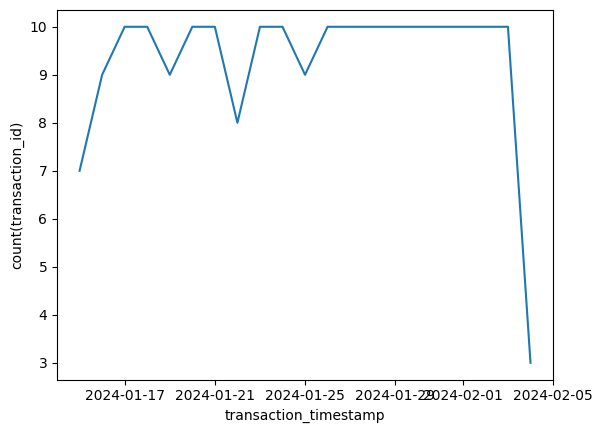

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
daily_trend_pd = daily_trend.toPandas()

plt.figure()
sns.lineplot(x='transaction_timestamp', y='count(transaction_id)', data=daily_trend_pd)

plt.show()

6. Data Integration & Advanced Features
Join Operations: Join transactional data with a reference dataset (Product name, Brand) using optimization techniques like Broadcast Joins.

Tracking: Utilize Accumulators to track specific metrics (e.g., total invalid records) across the cluster.

In [22]:
from pyspark.sql.functions import broadcast

df2.join(broadcast(df), "product_id").show()

+----------+--------------+--------+-------------+------+--------+---------------------+--------+-------+--------------------+-------------+
|product_id|transaction_id| user_id|     category| price|quantity|transaction_timestamp|platform|country|        product_name|        brand|
+----------+--------------+--------+-------------+------+--------+---------------------+--------+-------+--------------------+-------------+
|   prod051|        txn151|user1151|       sports| 355.0|       1|  2024-01-30 08:30:45|  mobile|    usa|      skateboard pro|extremesports|
|   prod033|        txn133|user1133|      fashion| 135.0|       1|  2024-01-28 10:22:15|  mobile|germany|    formal suit navy| businesswear|
|   prod039|        txn039|user1039|  electronics|899.99|       1|  2024-01-18 16:30:15|  mobile| canada|      wireless mouse| computerplus|
|   prod007|        txn107|user1107|      fashion|  45.0|       2|  2024-01-25 14:22:35|  mobile| france|casual cotton t-s...|    stylewear|
|   prod045| 

In [23]:
invalid_counter = spark.sparkContext.accumulator(0)

df2.foreach(
    lambda row: invalid_counter.add(1) if (
        row.transaction_id is None or
        row.user_id is None or
        row.product_id is None
    ) else None
)

print("Total Invalid Records:", invalid_counter.value)

Total Invalid Records: 0


7. Output Management
Write the final processed dataset to the local filesystem.

The output must use a columnar storage format.

Partitioning: Organize the output folder by a logical business column.

In [24]:
df2.write.mode('overwrite').partitionBy('country').parquet('/content/data')

In [27]:
df2.coalesce(1).write.mode("overwrite").parquet("/content/output")

import os

files = os.listdir("output/")
for file in files:
    if file.endswith(".parquet"):
        os.rename(f"output/{file}", "output/my_file.parquet")